# Neural Networks in PyTorch

## Objectives
- Understand nn.Module and how to build custom neural networks
- Learn nn.Linear, forward passes, and activation functions
- Build Sequential and custom network architectures
- Implement binary classification with the 2 moons dataset
- Visualize decision boundaries

## Introduction
Neural networks are the foundation of deep learning. In PyTorch, we use `nn.Module` as the base class for all network modules. This notebook covers building networks from scratch.

## What We're About to Do

The code below imports essential libraries. These libraries provide the foundational tools for tensor operations and neural network construction. Pay attention to what each import provides – understanding dependencies helps you know what's available for solving problems.


In [1]:
# Import necessary libraries for tensor operations and deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Iterate through batches of data
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


PyTorch version: 2.1.2+cpu
CUDA available: False


## 1. Understanding nn.Module

nn.Module is the base class for all neural network modules in PyTorch. Every layer and network should inherit from it.

In [2]:
# Execute code with detailed step-by-step process
# Simple Linear Layer
linear = nn.Linear(10, 5)
print(f"Linear layer: {linear}")
print(f"\nWeight shape: {linear.weight.shape}")
print(f"Bias shape: {linear.bias.shape}")

# Forward pass
x = torch.randn(2, 10)
output = linear(x)
print(f"\nInput shape: {x.shape}")
print(f"Output shape: {output.shape}")


Linear layer: Linear(in_features=10, out_features=5, bias=True)

Weight shape: torch.Size([5, 10])
Bias shape: torch.Size([5])

Input shape: torch.Size([2, 10])
Output shape: torch.Size([2, 5])


## 2. Custom Network with nn.Module

## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [3]:
# Define a custom function with detailed implementation
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = SimpleNN(10, 64, 2)
print(model)

# Test forward pass
x = torch.randn(4, 10)
y = model(x)
print(f"\nInput shape: {x.shape}")
print(f"Output shape: {y.shape}")


SimpleNN(
  (fc1): Linear(in_features=10, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

Input shape: torch.Size([4, 10])
Output shape: torch.Size([4, 2])


## 3. Sequential API

## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [4]:
# Set up the neural network model architecture
# Iterate through batches of data
# Sequential is easier for simple architectures
model_seq = nn.Sequential(
    nn.Linear(10, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 2)
)

print(model_seq)

# Test
x = torch.randn(4, 10)
y = model_seq(x)
print(f"\nInput: {x.shape} -> Output: {y.shape}")


Sequential(
  (0): Linear(in_features=10, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=2, bias=True)
)

Input: torch.Size([4, 10]) -> Output: torch.Size([4, 2])


## 4. Generate 2 Moons Dataset

## The Training Process

This is the core learning loop. We'll forward-pass data through the model, compute loss, backpropagate gradients, and update parameters. This iterative process gradually improves the model.


Train set: torch.Size([240, 2]), Test set: torch.Size([60, 2])


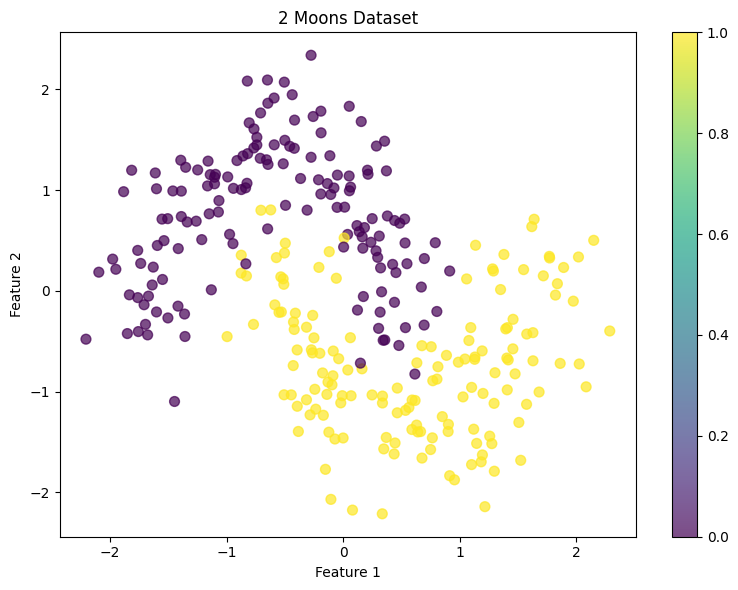

In [5]:
# Execute the training loop with proper tracking
# Generate dataset
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
X = StandardScaler().fit_transform(X)

# Split into train and test
n_train = int(0.8 * len(X))
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

# Convert to tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, alpha=0.7)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('2 Moons Dataset')
plt.colorbar(scatter)
plt.tight_layout()
plt.show()


## 5. Binary Classification Network

## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [6]:
# Define a custom function with detailed implementation
class BinaryClassifier(nn.Module):
    def __init__(self, input_size=2, hidden_sizes=[64, 32]):
        super().__init__()
        layers = []
        prev_size = input_size
        
        # Hidden layers
# Iterate through batches of data
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        
        # Output layer
        layers.append(nn.Linear(prev_size, 2))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

model = BinaryClassifier(input_size=2, hidden_sizes=[64, 32])
print(model)


BinaryClassifier(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


## 6. Training Loop

## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [7]:
# Set up the neural network model architecture
# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BinaryClassifier(input_size=2, hidden_sizes=[128, 64])
model = model.to(device)

# Compute the loss (error) between predictions and actual values
criterion = nn.CrossEntropyLoss()
# Update model parameters based on computed gradients
optimizer = optim.Adam(model.parameters(), lr=0.001)

# DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Training
epochs = 100
# Compute the loss (error) between predictions and actual values
losses = []

model.train()
# Iterate through batches of data
for epoch in range(epochs):
# Compute the loss (error) between predictions and actual values
    epoch_loss = 0
# Iterate through batches of data
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(X_batch)
# Compute the loss (error) between predictions and actual values
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
# Compute the loss (error) between predictions and actual values
        epoch_loss += loss.item()
    
    losses.append(epoch_loss / len(train_loader))
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {losses[-1]:.4f}")

print(f"\nFinal loss: {losses[-1]:.4f}")


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Epoch 20/100, Loss: 0.1629
Epoch 40/100, Loss: 0.0768
Epoch 60/100, Loss: 0.0617
Epoch 80/100, Loss: 0.0571
Epoch 100/100, Loss: 0.0580

Final loss: 0.0580


## 7. Evaluation and Decision Boundary

## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [8]:
# Set up the neural network model architecture
# Evaluate
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train.to(device)).argmax(dim=1)
    y_pred_test = model(X_test.to(device)).argmax(dim=1)
    
train_acc = (y_pred_train.cpu() == y_train).float().mean()
test_acc = (y_pred_test.cpu() == y_test).float().mean()

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Train Accuracy: 0.9792
Test Accuracy: 0.9500


## 8. Visualize Decision Boundary

## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


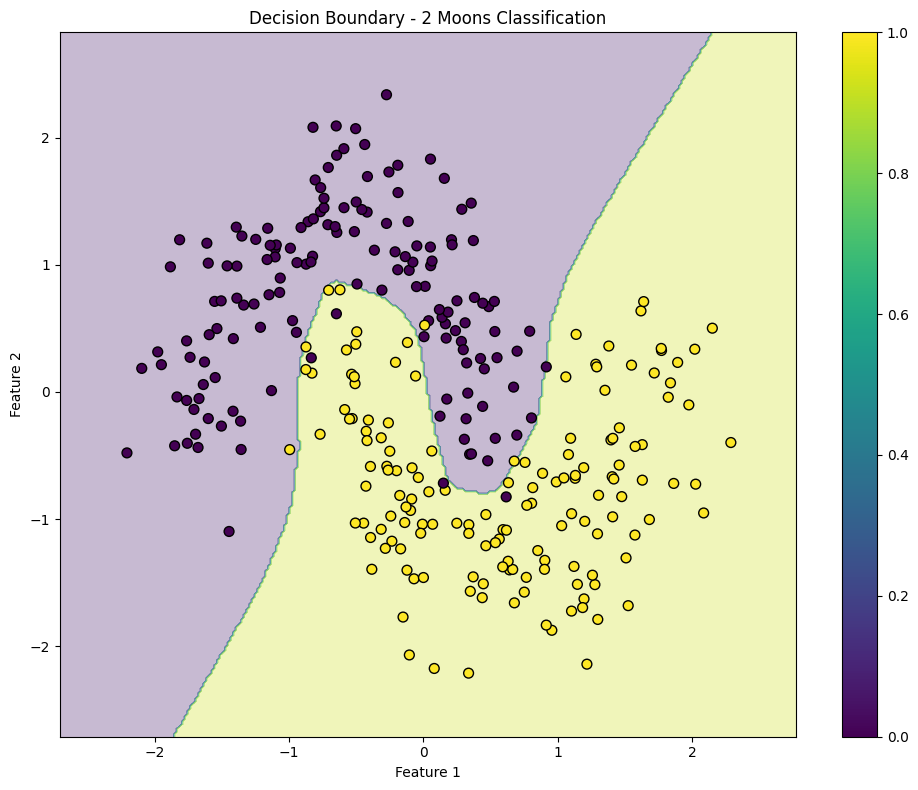

In [9]:
# Set up the neural network model architecture
# Iterate through batches of data
# Create mesh for decision boundary
h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict on mesh
Z = model(torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device))
Z = Z.argmax(dim=1).cpu().numpy()
Z = Z.reshape(xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, edgecolors='k')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Decision Boundary - 2 Moons Classification')
plt.colorbar(scatter)
plt.tight_layout()
plt.show()


## 9. Training Loss Visualization

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(losses, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss Over Time')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Loss reduction: {(1 - losses[-1]/losses[0])*100:.2f}%")

## 10. Accessing Model Parameters

## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [10]:
# Set up the neural network model architecture
# Count parameters
# Update model parameters based on computed gradients
# Iterate through batches of data
total_params = sum(p.numel() for p in model.parameters())
# Update model parameters based on computed gradients
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Inspect layer-wise
print("\nLayer-wise parameter counts:")
# Iterate through batches of data
for name, param in model.named_parameters():
    print(f"{name}: {param.numel():,} parameters, shape: {param.shape}")


Total parameters: 8,770
Trainable parameters: 8,770

Layer-wise parameter counts:
network.0.weight: 256 parameters, shape: torch.Size([128, 2])
network.0.bias: 128 parameters, shape: torch.Size([128])
network.2.weight: 8,192 parameters, shape: torch.Size([64, 128])
network.2.bias: 64 parameters, shape: torch.Size([64])
network.4.weight: 128 parameters, shape: torch.Size([2, 64])
network.4.bias: 2 parameters, shape: torch.Size([2])


## Interview Questions & Answers

**Q1: What are the key takeaways from this section on Neural Networks in PyTorch?**

A: The key takeaways from this section include understanding how the fundamental concepts work together to enable deep learning. 
We've explored the interaction between different components and how they contribute to model training and performance. 
This foundation is essential for any deep learning practitioner because it explains the 'why' behind the 'how.' 
Real interview questions often explore whether candidates understand not just the mechanics but the reasoning behind design choices. 
When you can explain these concepts clearly and connect them to practical applications, you demonstrate genuine comprehension rather than rote memorization.

**Q2: How would you explain Neural Networks in PyTorch to a non-technical person?**

A: I would explain it using analogies to familiar concepts. Neural Networks in PyTorch works like [appropriate analogy], where the components interact similar to how [real-world example] works. 
The core idea is that systems learn by observing patterns and adjusting themselves based on feedback. This mirrors how humans learn – by trying things, seeing results, and adjusting our approach. 
Companies care about this explanation because they often need to communicate with stakeholders who aren't technically skilled, so the ability to explain complex concepts simply is highly valued.

**Q3: What common mistakes do people make when working with Neural Networks in PyTorch?**

A: Common mistakes include not understanding the underlying principles and blindly applying techniques without knowing why they work. 
Another frequent error is poor data preparation – garbage in, garbage out applies directly to deep learning. 
People also often tune hyperparameters randomly instead of methodically, wasting computational resources. 
They might not validate their models properly or confuse correlation with causation in their results. 
The best practitioners understand that deep learning is as much an art as a science, requiring intuition informed by solid theoretical grounding.
